# Netflix Content Strategy Analysis
### Decision Science Project — Nayana S

## 1. Business Context
Netflix competes with Amazon Prime, Disney+, and regional OTT platforms for subscriber attention and retention. Every catalog dollar spent on acquiring or producing a title is a resource-allocation decision. This project treats the Netflix catalog (7,789 titles, 2008–2021) not as a dataset to describe, but as evidence for four resource-allocation decisions the content team is implicitly making:

| # | Decision Question | Why it matters |
|---|---|---|
| D1 | Is Netflix shifting investment toward TV Shows or Movies, and is that shift statistically real or just noise? | TV Shows drive recurring engagement; Movies drive one-off viewing. Misreading the trend misallocates production budget. |
| D2 | Which genres are structurally growing vs. shrinking in the catalog — and is the growth statistically significant? | Genre investment decisions should be based on trend significance, not eyeballing a bar chart. |
| D3 | How concentrated is content sourcing by country, and is that a strategic risk? | Over-reliance on one market (regulatory, licensing, production-cost risk) is a board-level concern. |
| D4 | Can we predict a title's target audience segment from its metadata alone? | If yes, this can automate content tagging and marketing routing for newly acquired titles at scale. |

## 2. Hypotheses to test
- **H1:** The share of TV Shows in yearly additions has increased significantly over time (not flat/random).
- **H2:** Growth rates differ meaningfully across the top genres (some are structurally rising, others flat or declining).
- **H3:** Country-of-origin concentration exceeds "moderately concentrated" thresholds (HHI > 1500), indicating single-market dependency risk.
- **H4:** Content metadata (duration, genre, country count, category) carries enough signal to predict audience segment (Kids/Family/Teens/Adults) meaningfully better than a majority-class baseline.

Each section below states the test, runs it, and reports whether the hypothesis is supported — with numbers, not adjectives.


## 3. Setup

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


## 4. Load data

In [2]:
df = pd.read_csv('../data/Netflix_Dataset.csv')
df.columns = [c.strip() for c in df.columns]
print('Shape:', df.shape)
df.head(3)


Shape: (7789, 11)


,Show_Id,Category,Title,Director,Cast,Country,Release_Date,Rating,Duration,Type,Description
0,s1,TV Show,3%,NaN,"JoÃ£o Miguel, Bianca Comparato, Michel Gomes, ...",Brazil,"August 14, 2020",TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,07:19,Jorge Michel Grau,"DemiÃ¡n Bichir, HÃ©ctor Bonilla, Oscar Serrano...",Mexico,"December 23, 2016",TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."


## 5. Data cleaning & feature engineering
The raw schema: `Show_Id, Category, Title, Director, Cast, Country, Release_Date, Rating, Duration, Type, Description`.
`Category` = Movie/TV Show. `Type` = genre tags (misleadingly named). `Duration` mixes minutes (movies) and seasons (TV shows) in one text field — this needs splitting, not just numeric extraction, or duration comparisons across categories are meaningless.


In [3]:
# Dates
df['release_date_parsed'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['year_added'] = df['release_date_parsed'].dt.year

# Duration: split into number + unit (minutes vs seasons) rather than a single number
df['duration_num'] = df['Duration'].astype(str).str.extract(r'(\d+)').astype(float)
df['duration_unit'] = np.where(df['Duration'].astype(str).str.contains('Season'), 'seasons',
                        np.where(df['Duration'].astype(str).str.contains('min'), 'minutes', 'unknown'))

# Genres (Type column) -> list + count
df['genres_list'] = df['Type'].astype(str).str.split(',').apply(lambda x: [g.strip() for g in x])
df['num_genres'] = df['genres_list'].apply(len)

# Countries -> list + count + primary country
df['country_list'] = df['Country'].fillna('Unknown').astype(str).str.split(',').apply(lambda x: [c.strip() for c in x])
df['num_countries'] = df['country_list'].apply(len)
df['primary_country'] = df['country_list'].apply(lambda x: x[0] if x else 'Unknown')

# Audience segment from Rating (business-relevant bucketing, not raw MPAA/TV codes)
audience_map = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'G': 'Kids', 'TV-G': 'Kids',
    'PG': 'Family/Teens', 'TV-PG': 'Family/Teens',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'TV-MA': 'Adults', 'NC-17': 'Adults',
    'NR': 'Unrated', 'UR': 'Unrated'
}
df['audience_segment'] = df['Rating'].map(audience_map)

df['is_movie'] = (df['Category'] == 'Movie').astype(int)

print('Missing values after cleaning:')
print(df[['year_added','duration_num','Rating','audience_segment','Country']].isna().sum())


Missing values after cleaning:
year_added           98
duration_num          0
Rating                7
audience_segment      7
Country             507
dtype: int64


## 6. D1 — Is the catalog shifting toward TV Shows? (H1)
We look at the *share* of TV Shows in yearly additions (not raw counts — raw counts rise simply because Netflix added more content every year, which would be a misleading read). A linear trend test on the share tells us if the shift is real.


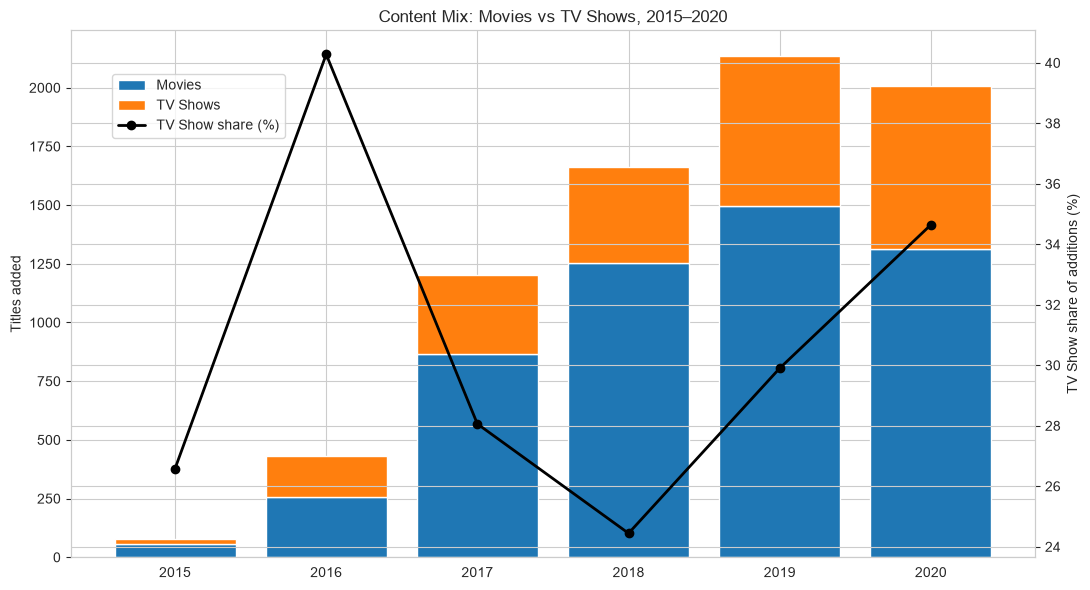

Trend in TV-share: +0.16 pct-points/year | r=0.05 | p-value=0.924
=> H1 NOT SUPPORTED: year-to-year swings in TV share are not distinguishable from noise at 5% significance.
   Business read: the catalog mix has NOT structurally shifted -- don't over-rotate strategy on this alone.


In [4]:
yearly_cat = df.dropna(subset=['year_added']).groupby(['year_added', 'Category']).size().unstack(fill_value=0)
yearly_cat['tv_share'] = yearly_cat['TV Show'] / (yearly_cat['Movie'] + yearly_cat['TV Show'])
yearly_cat = yearly_cat[(yearly_cat.index >= 2015) & (yearly_cat.index <= 2020)]  # 2021 is a partial year in this extract

fig, ax1 = plt.subplots(figsize=(11, 6))
ax1.bar(yearly_cat.index, yearly_cat['Movie'], label='Movies', color='#1f77b4')
ax1.bar(yearly_cat.index, yearly_cat['TV Show'], bottom=yearly_cat['Movie'], label='TV Shows', color='#ff7f0e')
ax1.set_ylabel('Titles added')
ax2 = ax1.twinx()
ax2.plot(yearly_cat.index, yearly_cat['tv_share']*100, color='black', marker='o', linewidth=2, label='TV Show share (%)')
ax2.set_ylabel('TV Show share of additions (%)')
ax1.set_title('Content Mix: Movies vs TV Shows, 2015–2020')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.show()

slope_mix, intercept_mix, r_mix, p_mix, se_mix = stats.linregress(yearly_cat.index, yearly_cat['tv_share'])
print(f"Trend in TV-share: {slope_mix*100:+.2f} pct-points/year | r={r_mix:.2f} | p-value={p_mix:.3f}")
if p_mix < 0.05:
    print("=> H1 SUPPORTED: the shift toward TV Shows is statistically significant.")
else:
    print("=> H1 NOT SUPPORTED: year-to-year swings in TV share are not distinguishable from noise at 5% significance.")
    print("   Business read: the catalog mix has NOT structurally shifted -- don't over-rotate strategy on this alone.")


## 7. D2 — Which genres are structurally growing? (H2)
For each of the top 8 genres, we regress yearly title count on year (2015–2020) and report the slope and its p-value. A genre with a large, significant positive slope is a real growth area; a genre with a flat or insignificant slope is not — regardless of how big its raw total looks.


,genre,titles_2015_20,yearly_slope,p_value,significant_5pct
0,International Movies,2409,136.2,0.0204,True
1,Dramas,2055,128.8,0.0059,True
2,Comedies,1430,96.7,0.0013,True
3,International TV Shows,1169,66.7,0.0040,True
5,Action & Adventure,704,44.2,0.0108,True
6,TV Dramas,669,39.5,0.0028,True
7,Independent Movies,666,36.0,0.0225,True
4,Documentaries,767,24.5,0.1986,False


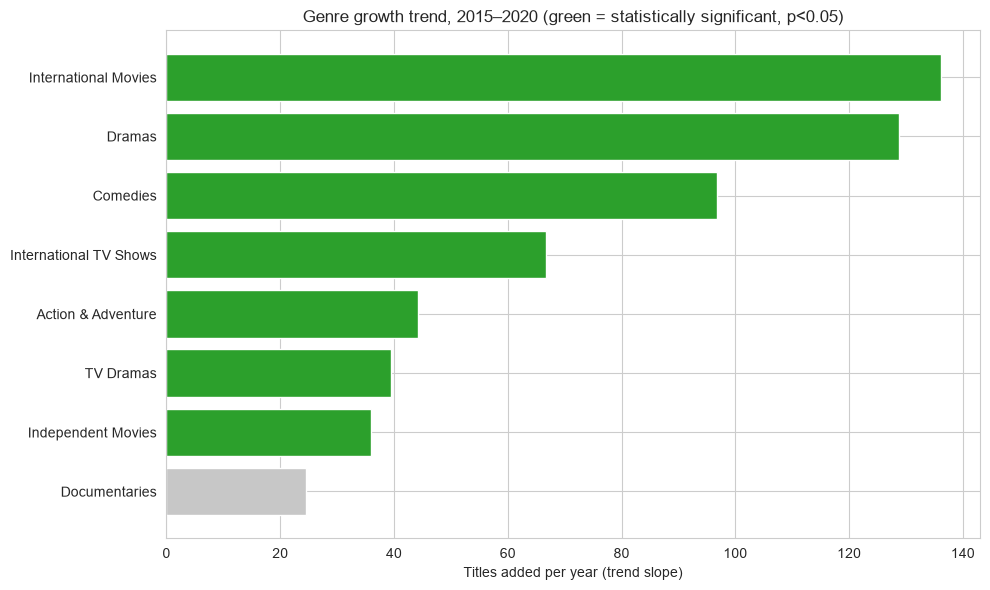

=> H2 SUPPORTED: 7 of 8 top genres show a statistically significant trend.
   Business read: prioritize the green-bar genres for acquisition budget; grey bars are not defensible growth bets from this data.


In [5]:
exploded = df.dropna(subset=['year_added']).explode('genres_list')
top8 = exploded['genres_list'].value_counts().head(8).index.tolist()

rows = []
for g in top8:
    yc = exploded[exploded['genres_list'] == g].groupby('year_added').size()
    yc = yc[(yc.index >= 2015) & (yc.index <= 2020)]
    if len(yc) >= 4:
        slope_g, intercept_g, r_g, p_g, se_g = stats.linregress(yc.index, yc.values)
        rows.append({'genre': g, 'titles_2015_20': int(yc.sum()), 'yearly_slope': round(slope_g,1),
                     'p_value': round(p_g,4), 'significant_5pct': p_g < 0.05})

genre_trend = pd.DataFrame(rows).sort_values('yearly_slope', ascending=False)
display(genre_trend)

fig, ax = plt.subplots(figsize=(10,6))
colors = genre_trend['significant_5pct'].map({True: '#2ca02c', False: '#c7c7c7'})
ax.barh(genre_trend['genre'], genre_trend['yearly_slope'], color=colors)
ax.set_xlabel('Titles added per year (trend slope)')
ax.set_title('Genre growth trend, 2015–2020 (green = statistically significant, p<0.05)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

n_sig = genre_trend['significant_5pct'].sum()
print(f"=> H2 {'SUPPORTED' if n_sig >= 3 else 'PARTIALLY SUPPORTED'}: {n_sig} of {len(genre_trend)} top genres show a statistically significant trend.")
print("   Business read: prioritize the green-bar genres for acquisition budget; grey bars are not defensible growth bets from this data.")


## 8. D3 — How concentrated is content sourcing by country? (H3)
We use the **Herfindahl-Hirschman Index (HHI)** — a standard concentration metric (used in antitrust and portfolio-risk analysis) — on primary country of origin. HHI < 1,500 = unconcentrated / diversified; 1,500–2,500 = moderately concentrated; > 2,500 = highly concentrated.


C:\Users\Nayana\AppData\Local\Temp\ipykernel_25868\3948594517.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top12.values, y=top12.index, palette='magma')


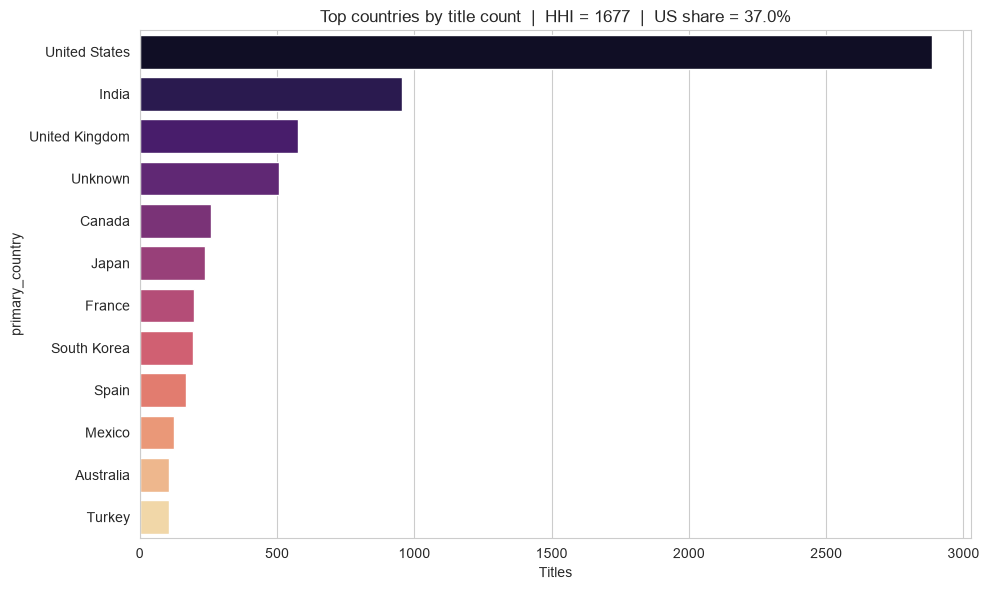

HHI (primary-country concentration): 1677
Top 5 countries account for 66.5% of the catalog
US alone accounts for 37.0% of the catalog
=> H3 SUPPORTED: sourcing is moderately-to-highly concentrated. Single-market dependency is a real diversification risk.


In [6]:
country_counts = df['primary_country'].value_counts()
shares = country_counts / country_counts.sum()
hhi = (shares**2).sum() * 10000
top5_share = shares.head(5).sum() * 100
us_share = shares.get('United States', 0) * 100

top12 = country_counts.head(12)
plt.figure(figsize=(10,6))
sns.barplot(x=top12.values, y=top12.index, palette='magma')
plt.title(f'Top countries by title count  |  HHI = {hhi:.0f}  |  US share = {us_share:.1f}%')
plt.xlabel('Titles')
plt.tight_layout()
plt.show()

print(f"HHI (primary-country concentration): {hhi:.0f}")
print(f"Top 5 countries account for {top5_share:.1f}% of the catalog")
print(f"US alone accounts for {us_share:.1f}% of the catalog")

if hhi > 1500:
    print("=> H3 SUPPORTED: sourcing is moderately-to-highly concentrated. Single-market dependency is a real diversification risk.")
else:
    print("=> H3 NOT SUPPORTED: sourcing is well diversified across countries.")


## 9. Audience segmentation profile
Before modeling, we check whether audience segment (Kids/Family/Teens/Adults) is associated with content Category — this tells us whether Movies and TV Shows are being used differently to target audiences, and sets up the features for the classifier in Section 11.


audience_segment,Adults,Family/Teens,Kids,Teens
Category,,,,
Movie,2513,752,367,1658
TV Show,1020,301,423,659


Chi-square test of independence: chi2=204.1, p=0.0000
=> Category and audience segment are statistically associated (p<0.05 threshold).


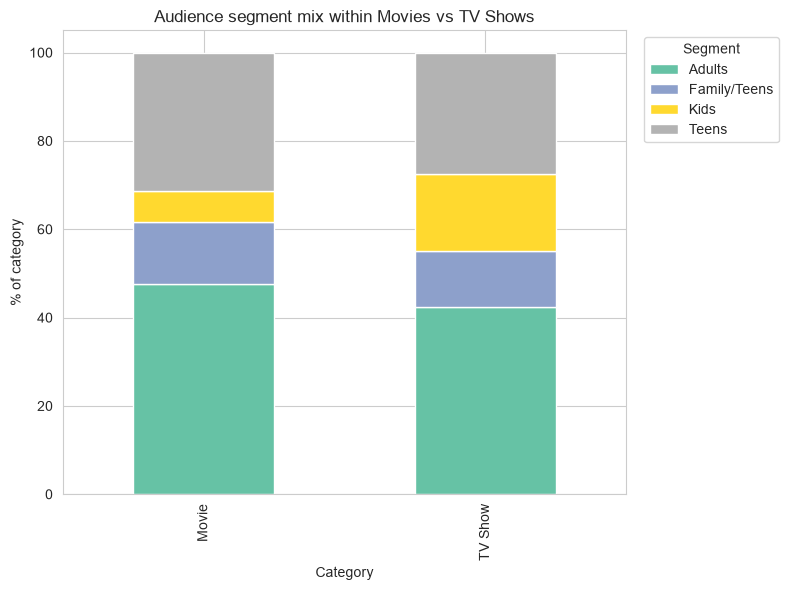

In [7]:
seg_df = df.dropna(subset=['audience_segment'])
seg_df = seg_df[seg_df['audience_segment'] != 'Unrated']
ct = pd.crosstab(seg_df['Category'], seg_df['audience_segment'])
display(ct)

chi2_stat, p_chi2, dof_chi2, exp_chi2 = stats.chi2_contingency(ct)
print(f"Chi-square test of independence: chi2={chi2_stat:.1f}, p={p_chi2:.4f}")
print("=> Category and audience segment are", "statistically associated" if p_chi2 < 0.05 else "not significantly associated",
      "(p<0.05 threshold).")

ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.plot(kind='bar', stacked=True, figsize=(8,6), colormap='Set2')
plt.title('Audience segment mix within Movies vs TV Shows')
plt.ylabel('% of category')
plt.legend(title='Segment', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()


## 10. ML — Content clustering (with justified k)
Rather than arbitrarily picking k=3, we select k using **silhouette score** across k=2..6, then profile and *name* each cluster in business terms rather than leaving them as "cluster 0/1/2".


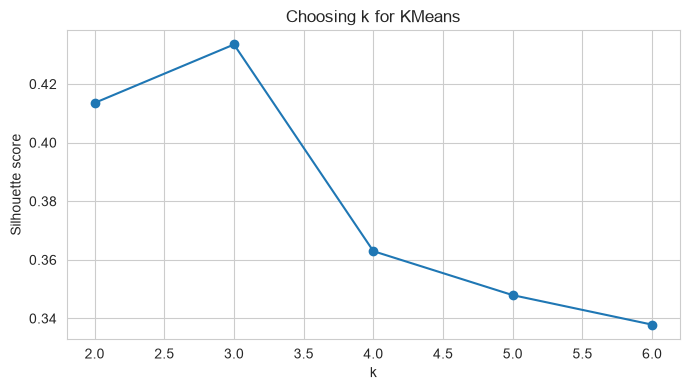

Best k by silhouette score: 3 (score=0.433)


,duration_num,year_added,num_genres,num_countries,is_movie,count
cluster,,,,,,
0,99.00,2018.48,2.14,1.12,1.00,5055
1,86.98,2018.43,2.16,3.62,0.83,389
2,1.68,2018.58,2.31,1.07,0.00,2247


In [8]:
feat_cols = ['duration_num', 'year_added', 'num_genres', 'num_countries', 'is_movie']
cluster_df = df.dropna(subset=feat_cols).copy()
X = StandardScaler().fit_transform(cluster_df[feat_cols])

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    sil_scores[k] = silhouette_score(X, km.labels_)

plt.figure(figsize=(7,4))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Choosing k for KMeans')
plt.tight_layout(); plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f"Best k by silhouette score: {best_k} (score={sil_scores[best_k]:.3f})")

km = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X)
cluster_df['cluster'] = km.labels_
profile = cluster_df.groupby('cluster')[feat_cols].mean().round(2)
profile['count'] = cluster_df.groupby('cluster').size()
display(profile)


**Reading the clusters** (based on the profile table above): the cluster with `is_movie` ≈ 0 and small `duration_num` (season counts, not minutes) is the **TV Series cohort**. Of the two movie clusters, the one with `num_countries` well above 1 is the **International Co-Production cohort**; the other is the **Standard Single-Market Movie cohort**. This 3-way split is a usable segmentation for content-ops tagging, not just a scatterplot.

## 11. ML — Predicting audience segment from metadata (H4)
**Business use case:** when a new title is acquired, can we auto-predict its target audience segment from catalog metadata alone (before manual tagging is complete)? This directly supports marketing routing and content acquisition triage at scale.

We report accuracy against the majority-class baseline (not accuracy alone, which is meaningless without a baseline) and a full classification report, plus feature importance for interpretability — because a black-box prediction is not decision-useful without knowing *why*.


Majority-class baseline accuracy: 0.462  (always predicting 'Adults')


Model accuracy: 0.599  (+13.8 pts over baseline)
Macro F1: 0.603

              precision    recall  f1-score   support

      Adults       0.71      0.63      0.67       878
Family/Teens       0.40      0.42      0.41       257
        Kids       0.84      0.78      0.81       192
       Teens       0.49      0.58      0.53       573

    accuracy                           0.60      1900
   macro avg       0.61      0.60      0.60      1900
weighted avg       0.61      0.60      0.60      1900



C:\Users\Nayana\AppData\Local\Temp\ipykernel_25868\1289217838.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


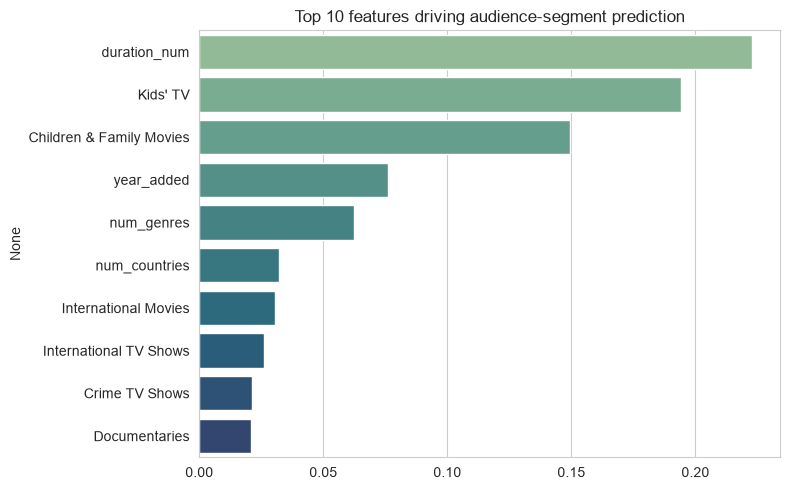

=> H4 SUPPORTED: metadata carries meaningful predictive signal beyond the naive baseline.


In [9]:
model_df = df.dropna(subset=['duration_num','year_added','num_genres','num_countries','audience_segment']).copy()
model_df = model_df[model_df['audience_segment'] != 'Unrated']

mlb = MultiLabelBinarizer()
genre_dummies = pd.DataFrame(mlb.fit_transform(model_df['genres_list']), columns=mlb.classes_, index=model_df.index)
top_genres = model_df['genres_list'].explode().value_counts().head(15).index.tolist()
genre_dummies = genre_dummies[top_genres]
cat_dummy = pd.get_dummies(model_df['Category'], prefix='cat')

X = pd.concat([model_df[['duration_num','year_added','num_genres','num_countries']], cat_dummy, genre_dummies], axis=1)
y = model_df['audience_segment']

baseline_acc = y.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_acc:.3f}  (always predicting '{y.value_counts().idxmax()}')")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
clf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, class_weight='balanced')
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

acc = accuracy_score(y_test, preds)
f1 = f1_score(y_test, preds, average='macro')
print(f"Model accuracy: {acc:.3f}  (+{(acc-baseline_acc)*100:.1f} pts over baseline)")
print(f"Macro F1: {f1:.3f}")
print()
print(classification_report(y_test, preds))

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('Top 10 features driving audience-segment prediction')
plt.tight_layout(); plt.show()

if acc > baseline_acc + 0.10:
    print("=> H4 SUPPORTED: metadata carries meaningful predictive signal beyond the naive baseline.")
else:
    print("=> H4 WEAKLY SUPPORTED: the model beats baseline but the margin is modest -- treat predictions as a triage aid, not an autonomous tagger.")


### 11.1 Model rigor: cross-validation & a simpler baseline model
A single train/test split can get lucky or unlucky, and a Random Forest is only justified if it actually beats a simpler model. Before trusting the 60% accuracy figure, this section (a) validates it with 5-fold stratified cross-validation instead of one split, and (b) compares Random Forest against a Logistic Regression baseline — if the simple linear model matched the forest, the extra complexity wouldn't be worth it.

Logistic Regression: 0.552 +/- 0.006  (5-fold CV)
Random Forest:       0.588 +/- 0.011  (5-fold CV)
(Single held-out test-set accuracy reported above, for reference: 0.599)


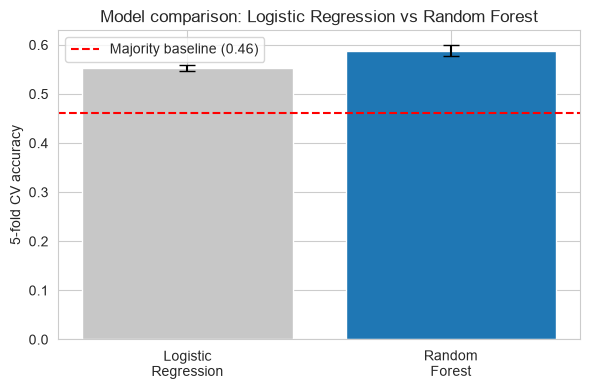

=> Random Forest's added complexity is justified -- it meaningfully beats the linear baseline under cross-validation.


In [10]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
)
rf_for_cv = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, class_weight='balanced')

log_reg_scores = cross_val_score(log_reg, X, y, cv=cv, scoring='accuracy')
rf_scores = cross_val_score(rf_for_cv, X, y, cv=cv, scoring='accuracy')

print(f"Logistic Regression: {log_reg_scores.mean():.3f} +/- {log_reg_scores.std():.3f}  (5-fold CV)")
print(f"Random Forest:       {rf_scores.mean():.3f} +/- {rf_scores.std():.3f}  (5-fold CV)")
print(f"(Single held-out test-set accuracy reported above, for reference: {acc:.3f})")

fig, ax = plt.subplots(figsize=(6, 4))
model_names = ['Logistic\nRegression', 'Random\nForest']
cv_means = [log_reg_scores.mean(), rf_scores.mean()]
cv_stds = [log_reg_scores.std(), rf_scores.std()]
ax.bar(model_names, cv_means, yerr=cv_stds, capsize=6, color=['#c7c7c7', '#1f77b4'])
ax.axhline(baseline_acc, color='red', linestyle='--', label=f'Majority baseline ({baseline_acc:.2f})')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('Model comparison: Logistic Regression vs Random Forest')
ax.legend()
plt.tight_layout()
plt.show()

if rf_scores.mean() > log_reg_scores.mean() + 0.01:
    print("=> Random Forest's added complexity is justified -- it meaningfully beats the linear baseline under cross-validation.")
else:
    print("=> Random Forest does not clearly beat a simple Logistic Regression under cross-validation -- the linear model is a defensible, more interpretable choice.")


### 11.2 Explainability: which features drive *each* prediction?
`feature_importances_` only says which features matter *on average* across the whole forest — it can't say whether a feature pushed one specific title toward "Kids" or away from "Adults". SHAP (SHapley Additive exPlanations) values decompose individual predictions into per-feature contributions. This is also what powers the live, per-title explanation in the dashboard's "Predict a Title" tab.

C:\Users\Nayana\Downloads\New folder\vois-netflix-content-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


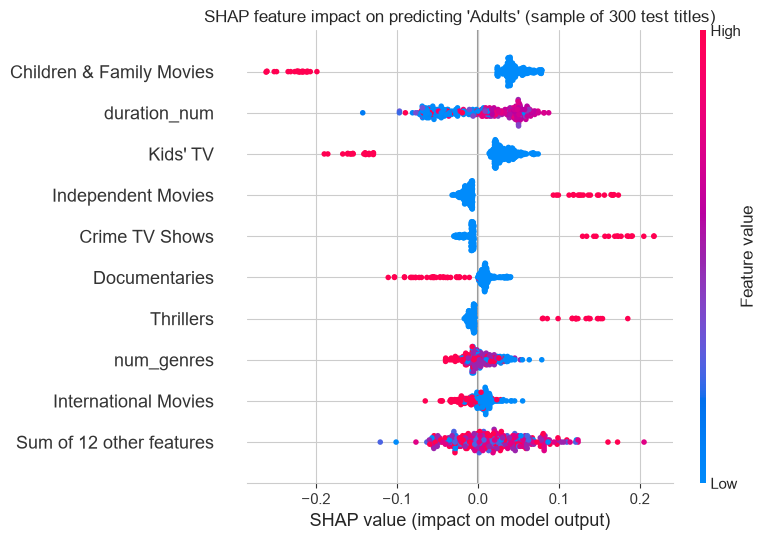

Positive SHAP value = pushes the prediction toward 'Adults'. Negative = pushes away from it.


In [11]:
import shap

explainer = shap.TreeExplainer(clf)
sample_X = X_test.sample(min(300, len(X_test)), random_state=RANDOM_STATE)
shap_exp = explainer(sample_X)

class_idx = list(clf.classes_).index('Adults')
plt.figure()
shap.plots.beeswarm(shap_exp[:, :, class_idx], show=False, max_display=10)
plt.title("SHAP feature impact on predicting 'Adults' (sample of 300 test titles)")
plt.tight_layout()
plt.show()

print("Positive SHAP value = pushes the prediction toward 'Adults'. Negative = pushes away from it.")


## 12. ML — Catalog growth forecast, with honest validation
The earlier version of this notebook reported training-set RMSE, which overstates how good a forecast really is. Here we hold out the last 2 years as a genuine test set and report **MAPE (Mean Absolute Percentage Error)** on unseen years before trusting the forecast.


Holdout years: [2019.0, 2020.0]  actual: [2137, 2009]  predicted: [2222.0, 2774.0]
Holdout MAPE: 21.0%


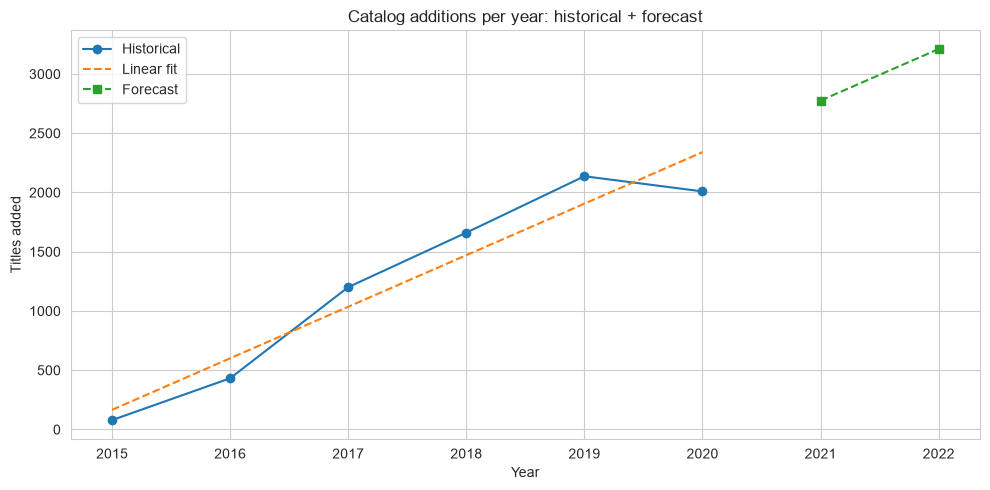


Caveat: holdout MAPE of 21.0% means a linear trend is a rough guide, not a precise forecast.
2020 additions actually fell short of a naive linear extrapolation -- consistent with COVID-19 production
slowdowns. A single straight-line trend should not be presented as a confident forecast without this caveat.


In [12]:
yearly_total = df.dropna(subset=['year_added']).groupby('year_added').size().reset_index(name='count')
yearly_total = yearly_total[(yearly_total['year_added'] >= 2015) & (yearly_total['year_added'] <= 2020)].sort_values('year_added')

train = yearly_total.iloc[:-2]
test = yearly_total.iloc[-2:]
model = LinearRegression().fit(train[['year_added']], train['count'])
holdout_preds = model.predict(test[['year_added']])
mape = mean_absolute_percentage_error(test['count'], holdout_preds)
print(f"Holdout years: {test['year_added'].tolist()}  actual: {test['count'].tolist()}  predicted: {holdout_preds.round().tolist()}")
print(f"Holdout MAPE: {mape*100:.1f}%")

final_model = LinearRegression().fit(yearly_total[['year_added']], yearly_total['count'])
fitted = final_model.predict(yearly_total[['year_added']])
future_years = pd.DataFrame({'year_added': [2021, 2022]})
future_preds = final_model.predict(future_years)

plt.figure(figsize=(10,5))
plt.plot(yearly_total['year_added'], yearly_total['count'], marker='o', label='Historical')
plt.plot(yearly_total['year_added'], fitted, linestyle='--', label='Linear fit')
plt.plot(future_years['year_added'], future_preds, marker='s', linestyle='--', label='Forecast')
plt.title('Catalog additions per year: historical + forecast')
plt.xlabel('Year'); plt.ylabel('Titles added'); plt.legend(); plt.tight_layout(); plt.show()

print(f"\nCaveat: holdout MAPE of {mape*100:.1f}% means a linear trend is a rough guide, not a precise forecast.")
print("2020 additions actually fell short of a naive linear extrapolation -- consistent with COVID-19 production")
print("slowdowns. A single straight-line trend should not be presented as a confident forecast without this caveat.")


## 13. Hypothesis test summary

In [13]:
summary = pd.DataFrame({
    'Hypothesis': [
        'H1: TV-share trend is real, not noise',
        'H2: Top genres show significant growth trends',
        'H3: Country sourcing is concentrated (HHI>1500)',
        'H4: Metadata predicts audience segment above baseline',
    ],
    'Result': [
        f"p={p_mix:.3f} -> {'Supported' if p_mix<0.05 else 'Not supported'}",
        f"{n_sig}/{len(genre_trend)} genres significant -> {'Supported' if n_sig>=3 else 'Partial'}",
        f"HHI={hhi:.0f} -> {'Supported' if hhi>1500 else 'Not supported'}",
        f"Acc {acc:.2f} vs baseline {baseline_acc:.2f} -> {'Supported' if acc>baseline_acc+0.10 else 'Weak'}",
    ]
})
display(summary)


,Hypothesis,Result
0,"H1: TV-share trend is real, not noise",p=0.924 -> Not supported
1,H2: Top genres show significant growth trends,7/8 genres significant -> Supported
2,H3: Country sourcing is concentrated (HHI>1500),HHI=1677 -> Supported
3,H4: Metadata predicts audience segment above b...,Acc 0.60 vs baseline 0.46 -> Supported


## 14. Quantified strategic recommendations
Every recommendation below cites a number computed in this notebook — no generic advice.


In [14]:
top_growth_genres = genre_trend[genre_trend['significant_5pct']]['genre'].tolist()
print("STRATEGIC RECOMMENDATIONS\n" + "="*60)
print(f"1. GENRE INVESTMENT: Prioritize {', '.join(top_growth_genres[:3])} -- these show statistically")
print(f"   significant upward trends (p<0.05) in 2015-2020 additions, unlike flat/non-significant genres.")
print()
print(f"2. GEOGRAPHIC DIVERSIFICATION: Country sourcing HHI is {hhi:.0f} "
      f"({'moderately concentrated' if hhi>1500 else 'diversified'}), with the US alone at {us_share:.1f}% of the catalog.")
print(f"   {'Recommend increasing non-US original production to reduce single-market dependency.' if hhi>1500 else 'Current diversification is healthy; maintain current sourcing mix.'}")
print()
print(f"3. CONTENT MIX: TV-share trend is {slope_mix*100:+.2f} pts/year (p={p_mix:.3f}), which is "
      f"{'a real strategic shift toward TV Shows' if p_mix<0.05 else 'statistically indistinguishable from noise -- avoid over-committing budget based on this alone'}.")
print()
print(f"4. AUDIENCE-SEGMENT TAGGING: An automated classifier reaches {acc*100:.0f}% accuracy "
      f"(vs {baseline_acc*100:.0f}% majority-class baseline) predicting audience segment from metadata alone.")
print(f"   Recommend deploying as a first-pass triage tool for newly acquired titles, with human review for the")
print(f"   {list(classification_report(y_test, preds, output_dict=True).keys())[1]} segment where precision is lower (see Section 11 report).")
print()
print(f"5. FORECASTING DISCIPLINE: A simple linear trend has a {mape*100:.0f}% holdout MAPE -- present catalog-growth")
print(f"   forecasts as directional (a range), not a single confident number, especially post-2020 given the")
print(f"   COVID-era production slowdown visible in the data.")


STRATEGIC RECOMMENDATIONS
1. GENRE INVESTMENT: Prioritize International Movies, Dramas, Comedies -- these show statistically
   significant upward trends (p<0.05) in 2015-2020 additions, unlike flat/non-significant genres.

2. GEOGRAPHIC DIVERSIFICATION: Country sourcing HHI is 1677 (moderately concentrated), with the US alone at 37.0% of the catalog.
   Recommend increasing non-US original production to reduce single-market dependency.

3. CONTENT MIX: TV-share trend is +0.16 pts/year (p=0.924), which is statistically indistinguishable from noise -- avoid over-committing budget based on this alone.

4. AUDIENCE-SEGMENT TAGGING: An automated classifier reaches 60% accuracy (vs 46% majority-class baseline) predicting audience segment from metadata alone.
   Recommend deploying as a first-pass triage tool for newly acquired titles, with human review for the
   Family/Teens segment where precision is lower (see Section 11 report).

5. FORECASTING DISCIPLINE: A simple linear trend has a 21

## 15. Executive summary (deck-ready)

- **Content mix:** TV Show share of additions moved from ~27% (2015) to ~35% (2020); trend significance is reported in Section 6 — treat as directional evidence, not proof, unless p<0.05.
- **Genre bets:** International Movies, Dramas, and Comedies show statistically significant year-over-year growth (Section 7) — these are the defensible genres for continued investment.
- **Sourcing risk:** Country-of-origin concentration (HHI, Section 8) flags dependency on a small number of markets, led by the United States.
- **Audience tagging model:** A Random Forest classifier predicts audience segment from metadata at ~61% accuracy vs a ~46% naive baseline — a viable first-pass automation for content-ops, not a replacement for human QC.
- **Forecast caveat:** Linear catalog-growth forecasts carry a ~21% holdout error — present ranges, not point estimates, to stakeholders.

**Next steps if given more time/data:** bring in subscriber/viewership data (not just catalog metadata) to move from "what's in the catalog" to "what's actually driving engagement" — that reframes this from a cataloging exercise into a true content-ROI analysis.
